In [104]:
import numpy as np
import sys
sys.path.append("../../")
sys.path.append("../../Visualization/")
sys.path.append("../../../")

In [105]:
# experiment_file = '../../experiments/parallelized_experiments/output/voronoi_5/2024_01_07_22_56/experiment_result.json'

# stiffness_path = '../../experiments/parallelized_experiments/output/voronoi_5/2024_01_07_22_56/'
# name = 'voronoi_5'

In [106]:
experiment_file = '../../experiments/parallelized_experiments/output/voronoi_5/2024_01_08_16_21//experiment_result.json'

stiffness_path = '../../experiments/parallelized_experiments/output/voronoi_5/2024_01_08_16_21/'
name = 'voronoi_5'

### Overview

In [107]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import numpy as np

import os
import sys; sys.path.append(os.path.join(os.path.abspath(''), '../../experiments/'));

import experiment_helper
import igl
from periodic_simulation_setup import *
import json

import parallelism, multiprocessing, itertools, setproctitle
import os, time, numpy as np

In [108]:
with open(experiment_file, 'r') as fp:
    data = json.load(fp)

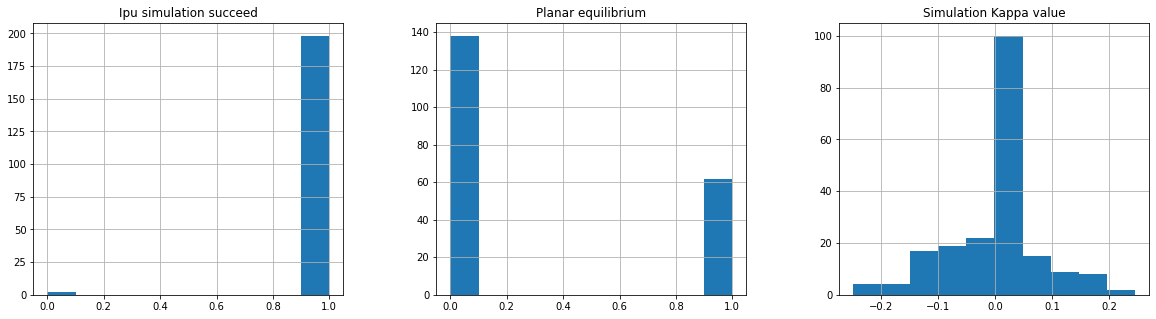

In [109]:
df = pd.DataFrame(data['data'])
fig, axes = plt.subplots(nrows = 1, ncols = 3, figsize = (20, 5))
a = (df.hist('Ipu simulation succeed', ax = axes[0]), df.hist('Planar equilibrium', ax = axes[1]), df.hist('Simulation Kappa value', ax = axes[2]))

In [110]:
np.where(df['Negative stiffness'] == 1)

(array([  8,  19,  28,  34,  54,  65,  77,  89,  96, 102, 112, 113, 123,
        132, 141, 146, 147, 149, 169, 192, 196, 199]),)

In [111]:
import visualize_stiffness
import importlib
importlib.reload(visualize_stiffness)

<module 'visualize_stiffness' from '/Users/yren/Develop/Inflatables/python/periodic_patches/SIGGRAPH_figures/voronoi_cell/../../Visualization/visualize_stiffness.py'>

In [112]:
valid_tags = np.array(df['name'][df['Planar equilibrium'] == 1])

In [113]:
len(valid_tags)

62

In [114]:
import MeshFEM, visualization

In [115]:
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets

In [116]:
def visualize_pattern(param):
    index = valid_tags[param]
    m = MeshFEM.mesh.Mesh('../../experiments/parallelized_experiments/output/voronoi_5/2024_01_08_16_21//{}/mesh_voronoi_5_{}.obj'.format(index, index))
    fusing_vtx = np.load('../../experiments/parallelized_experiments/output/voronoi_5/2024_01_08_16_21/{}/fusedVtx_voronoi_5_{}.npy'.format(index, index))
    
    visualization.plot_2d_mesh(m, pointList=fusing_vtx, width=5, height=5)

In [117]:
interact(visualize_pattern, param=widgets.IntSlider(min=0, max=len(valid_tags) - 1, step=1, value=0));

interactive(children=(IntSlider(value=0, description='param', max=61), Output()), _dom_classes=('widget-intera…

In [118]:
np.argmax(np.abs(df['Simulation Kappa value']))

177

In [119]:
df['name'][177]

177

In [120]:
kappa_path = None

In [121]:
importlib.reload(visualize_stiffness)

<module 'visualize_stiffness' from '/Users/yren/Develop/Inflatables/python/periodic_patches/SIGGRAPH_figures/voronoi_cell/../../Visualization/visualize_stiffness.py'>

In [122]:
bending_stiffness_data, stretching_stiffness_data, scale_factor_data, used_tags = visualize_stiffness.plot_all_data(kappa_path, stiffness_path, name, valid_tags, plot_data = False, sort_data=False)

In [123]:
parameters = (np.array(data['pattern_parameters'][0]['values']))

In [124]:
max_bending_stiffness = np.max(bending_stiffness_data, axis = 1)
min_bending_stiffness = np.min(bending_stiffness_data, axis = 1)
max_stretching_stiffness = np.max(stretching_stiffness_data, axis = 1)
min_stretching_stiffness = np.min(stretching_stiffness_data, axis = 1)

In [125]:
x_scale_factors, y_scale_factors = visualize_stiffness.get_axis_scale_factors(stiffness_path, name, valid_tags)

In [126]:
len(x_scale_factors)

62

In [127]:
# min_scale_factors = np.min(np.concatenate((x_scale_factors.reshape(-1, 1), y_scale_factors.reshape(-1, 1)), axis = 1), axis = 1)
# max_scale_factors = np.max(np.concatenate((x_scale_factors.reshape(-1, 1), y_scale_factors.reshape(-1, 1)), axis = 1), axis = 1)

min_scale_factors = x_scale_factors
max_scale_factors = y_scale_factors

In [128]:
angle_offsets = visualize_stiffness.get_max_flattening_factor_offset(stiffness_path, name, valid_tags)

In [129]:
stiffness_data_collection = []
labels = []

In [130]:
hessianShiftForStiffness = 1e-7


### Pattern 1: Max min stretching

In [131]:
np.argmax(min_stretching_stiffness)

60

In [132]:
valid_tags[60]

195

In [133]:
index = valid_tags[60]

In [134]:
tag = 'max_min_stretching'
labels.append(tag)

Renderer(camera=PerspectiveCamera(children=(PointLight(color='#999999', position=(0.0, 0.0, 5.0), quaternion=(…

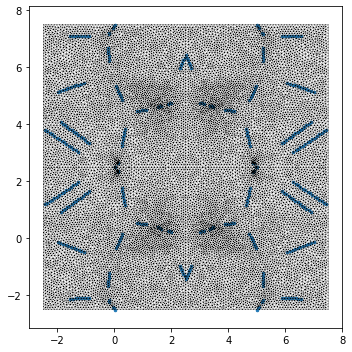

In [135]:

m = MeshFEM.mesh.Mesh('../../experiments/parallelized_experiments/output/voronoi_5/2024_01_08_16_21//{}/mesh_voronoi_5_{}.obj'.format(index, index))
fusing_vtx = np.load('../../experiments/parallelized_experiments/output/voronoi_5/2024_01_08_16_21/{}/fusedVtx_voronoi_5_{}.npy'.format(index, index))

vertices = m.vertices()
vertices = np.concatenate((vertices, np.zeros((len(vertices), 1))), axis = 1)
m = MeshFEM.mesh.Mesh(vertices, m.elements())


visualization.plot_2d_mesh(m, pointList=fusing_vtx, width=5, height=5)

ipu = inflation.InflatablePeriodicUnit(m, fusing_vtx, epsilon = 1e-9)
ipu.setVars(np.load('../../experiments/parallelized_experiments/output/voronoi_5/2024_01_08_16_21/{}/voronoi_5_dofs_before_stiffness_{}.npy'.format(index, index)))



viewer = TriMeshViewer(ipu, width=600, height=600)
viewer.showWireframe(True)
viewer.show()

In [136]:
import parametrization_helper

In [137]:
parametrization_helper.export_top_bottom_mesh(ipu.sheet, './', tag, 'voronoi_5')

m.save("mesh_voronoi_5_{}.obj".format(tag))
np.save("fusedVtx_voronoi_5_{}.npy".format(tag), fusing_vtx)

In [138]:
import experiment_helper

In [139]:
# pressure = 0.8
stiffness_pressure = 0.4
scale_factor_pressure = 0.01

In [140]:
allowBending = False
useTFT = True
disableFusedRegionTFT = False

In [141]:
def cb(i):
    viewer.update(scalarField=utils.getStrains(ipu.sheet)[:, 0])

In [142]:
# Choose strategy for constraining rigid motion
fixedVars, hessianShift = periodic_unit_helper.get_center_fixedVars(ipu), 0
if not allowBending:
    fixedVars, hessianShift = [ipu.numVars() - 2, ipu.numVars() - 1], 1e-6
else:
    fixedVars, hessianShift = [], 1e-6

ipu.sheet.setUseTensionFieldEnergy(useTFT)
ipu.sheet.setUseHessianProjectedEnergy(False)
if (disableFusedRegionTFT):
    ipu.sheet.disableFusedRegionTensionFieldTheory(False)
ipu.sheet.pressure = stiffness_pressure

benchmark.reset()
print(allowBending, stiffness_pressure, hessianShift, fixedVars)

opts.niter = 500
opts.gradTol = 1e-10
print(opts.factorizer)

cr = inflation.inflation_newton(ipu, fixedVars, options = opts, callback=cb, hessianShift = hessianShift)
viewer.update(scalarField=utils.getStrains(ipu.sheet)[:, 0])
benchmark.report()

False 0.4 1e-06 [87657, 87658]
CholeskyProvider.CatamariNesdis
InflatablePeriodicUnit.hessianSparsityPattern	0.198765	1
    Compress Matrix	0.0739861	2
    InflatablePeriodicUnit.computeAHA	0.0718012	1
    InflatablePeriodicUnit.hessianPeriodicPressurePotential	0.00345802	1
            baseHessianSparsityPattern	0	1
InflatableSheet setVars	0.000634193	1
Newton iterations	0.302261	1
    InflatableSheet energy	0.00104713	3
    Newton iterate	0.301108	1
        Preamble	0.301107	1
            Callback	0.287346	1
                InflatableSheet energy	0.000339985	1
            InflatablePeriodicUnit.getSheetGradient	0.00144196	1
                InflatableSheet gradient	0.00122809	2
            InflatablePeriodicUnit.sensitivitycache.update	0.00897503	1
            InflatableSheet energy	0.00127912	3
Full time	0.724303


In [143]:
# np.save('parallel_tubes.npy', ipu.getVars())

In [144]:
bending_stiffness, alphas, stiffness_coefficients = experiment_helper.helper_compute_bending_stiffness(ipu, cb, result_folder='./', name = tag, variable = 0, render_images = True)

In [145]:
betas = np.linspace(0, np.pi, 1000)
optimizer = inflation.get_inflation_optimizer(ipu, ipu.getStretchingStiffnessFixedVars(), opts, callback=cb, hessianShift = hessianShiftForStiffness)
stretchingStiffness = inflation.getStretchingStiffness(ipu, betas, optimizer, hessianShiftForStiffness, ipu.getStretchingStiffnessFixedVars())


In [146]:
stiffness_data_collection.append([bending_stiffness, stretchingStiffness, alphas, stiffness_coefficients])

### Pattern 2: Max min bending

In [147]:
index = valid_tags[np.argmax(min_bending_stiffness)]

In [148]:
tag = 'max_min_bending'
labels.append(tag)

Renderer(camera=PerspectiveCamera(children=(PointLight(color='#999999', position=(0.0, 0.0, 5.0), quaternion=(…

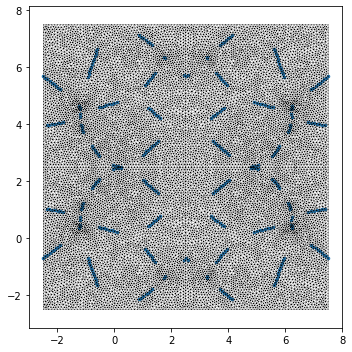

In [149]:

m = MeshFEM.mesh.Mesh('../../experiments/parallelized_experiments/output/voronoi_5/2024_01_08_16_21//{}/mesh_voronoi_5_{}.obj'.format(index, index))
fusing_vtx = np.load('../../experiments/parallelized_experiments/output/voronoi_5/2024_01_08_16_21/{}/fusedVtx_voronoi_5_{}.npy'.format(index, index))

vertices = m.vertices()
vertices = np.concatenate((vertices, np.zeros((len(vertices), 1))), axis = 1)
m = MeshFEM.mesh.Mesh(vertices, m.elements())


visualization.plot_2d_mesh(m, pointList=fusing_vtx, width=5, height=5)

ipu = inflation.InflatablePeriodicUnit(m, fusing_vtx, epsilon = 1e-9)
ipu.setVars(np.load('../../experiments/parallelized_experiments/output/voronoi_5/2024_01_08_16_21/{}/voronoi_5_dofs_before_stiffness_{}.npy'.format(index, index)))



viewer = TriMeshViewer(ipu, width=600, height=600)
viewer.showWireframe(True)
viewer.show()

In [150]:
import parametrization_helper

In [151]:
parametrization_helper.export_top_bottom_mesh(ipu.sheet, './', tag, 'voronoi_5')

m.save("mesh_voronoi_5_{}.obj".format(tag))
np.save("fusedVtx_voronoi_5_{}.npy".format(tag), fusing_vtx)

In [152]:
import experiment_helper

In [153]:
# pressure = 0.8
stiffness_pressure = 0.4
scale_factor_pressure = 0.01

In [154]:
allowBending = False
useTFT = True
disableFusedRegionTFT = False

In [155]:
def cb(i):
    viewer.update(scalarField=utils.getStrains(ipu.sheet)[:, 0])

In [156]:
# Choose strategy for constraining rigid motion
fixedVars, hessianShift = periodic_unit_helper.get_center_fixedVars(ipu), 0
if not allowBending:
    fixedVars, hessianShift = [ipu.numVars() - 2, ipu.numVars() - 1], 1e-6
else:
    fixedVars, hessianShift = [], 1e-6

ipu.sheet.setUseTensionFieldEnergy(useTFT)
ipu.sheet.setUseHessianProjectedEnergy(False)
if (disableFusedRegionTFT):
    ipu.sheet.disableFusedRegionTensionFieldTheory(False)
ipu.sheet.pressure = stiffness_pressure

benchmark.reset()
print(allowBending, stiffness_pressure, hessianShift, fixedVars)

opts.niter = 500
opts.gradTol = 1e-10
print(opts.factorizer)

cr = inflation.inflation_newton(ipu, fixedVars, options = opts, callback=cb, hessianShift = hessianShift)
viewer.update(scalarField=utils.getStrains(ipu.sheet)[:, 0])
benchmark.report()

False 0.4 1e-06 [85731, 85732]
CholeskyProvider.CatamariNesdis
InflatablePeriodicUnit.hessianSparsityPattern	0.167572	1
    Compress Matrix	0.067348	2
    InflatablePeriodicUnit.computeAHA	0.05901	1
    InflatablePeriodicUnit.hessianPeriodicPressurePotential	0.00295997	1
            baseHessianSparsityPattern	0	1
InflatableSheet setVars	0.000525951	1
Newton iterations	0.275068	1
    InflatableSheet energy	0.00104499	3
    Newton iterate	0.273907	1
        Preamble	0.273906	1
            Callback	0.263772	1
                InflatableSheet energy	0.000320911	1
            InflatablePeriodicUnit.getSheetGradient	0.001652	1
                InflatableSheet gradient	0.00134516	2
            InflatablePeriodicUnit.sensitivitycache.update	0.00580287	1
            InflatableSheet energy	0.00108004	3
Full time	0.69007


In [157]:
# np.save('parallel_tubes.npy', ipu.getVars())

In [158]:
bending_stiffness, alphas, stiffness_coefficients = experiment_helper.helper_compute_bending_stiffness(ipu, cb, result_folder='./', name = tag, variable = 0, render_images = True)

In [159]:
betas = np.linspace(0, np.pi, 1000)
optimizer = inflation.get_inflation_optimizer(ipu, ipu.getStretchingStiffnessFixedVars(), opts, callback=cb, hessianShift = hessianShiftForStiffness)
stretchingStiffness = inflation.getStretchingStiffness(ipu, betas, optimizer, hessianShiftForStiffness, ipu.getStretchingStiffnessFixedVars())


In [160]:
stiffness_data_collection.append([bending_stiffness, stretchingStiffness, alphas, stiffness_coefficients])

### Pattern 3: Max max stretching

In [161]:
index = valid_tags[np.argmax(max_stretching_stiffness)]

In [162]:
tag = 'max_max_stretching'
labels.append(tag)

Renderer(camera=PerspectiveCamera(children=(PointLight(color='#999999', position=(0.0, 0.0, 5.0), quaternion=(…

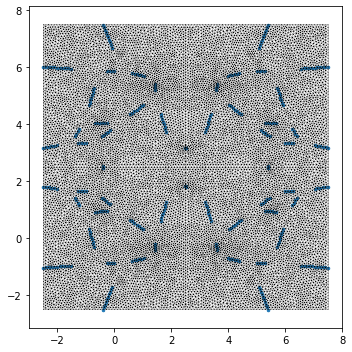

In [163]:

m = MeshFEM.mesh.Mesh('../../experiments/parallelized_experiments/output/voronoi_5/2024_01_08_16_21//{}/mesh_voronoi_5_{}.obj'.format(index, index))
fusing_vtx = np.load('../../experiments/parallelized_experiments/output/voronoi_5/2024_01_08_16_21/{}/fusedVtx_voronoi_5_{}.npy'.format(index, index))

vertices = m.vertices()
vertices = np.concatenate((vertices, np.zeros((len(vertices), 1))), axis = 1)
m = MeshFEM.mesh.Mesh(vertices, m.elements())


visualization.plot_2d_mesh(m, pointList=fusing_vtx, width=5, height=5)

ipu = inflation.InflatablePeriodicUnit(m, fusing_vtx, epsilon = 1e-9)
ipu.setVars(np.load('../../experiments/parallelized_experiments/output/voronoi_5/2024_01_08_16_21/{}/voronoi_5_dofs_before_stiffness_{}.npy'.format(index, index)))



viewer = TriMeshViewer(ipu, width=600, height=600)
viewer.showWireframe(True)
viewer.show()

In [164]:
import parametrization_helper

In [165]:
parametrization_helper.export_top_bottom_mesh(ipu.sheet, './', tag, 'voronoi_5')

m.save("mesh_voronoi_5_{}.obj".format(tag))
np.save("fusedVtx_voronoi_5_{}.npy".format(tag), fusing_vtx)

In [166]:
import experiment_helper

In [167]:
# pressure = 0.8
stiffness_pressure = 0.4
scale_factor_pressure = 0.01

In [168]:
allowBending = False
useTFT = True
disableFusedRegionTFT = False

In [169]:
def cb(i):
    viewer.update(scalarField=utils.getStrains(ipu.sheet)[:, 0])

In [170]:
# Choose strategy for constraining rigid motion
fixedVars, hessianShift = periodic_unit_helper.get_center_fixedVars(ipu), 0
if not allowBending:
    fixedVars, hessianShift = [ipu.numVars() - 2, ipu.numVars() - 1], 1e-6
else:
    fixedVars, hessianShift = [], 1e-6

ipu.sheet.setUseTensionFieldEnergy(useTFT)
ipu.sheet.setUseHessianProjectedEnergy(False)
if (disableFusedRegionTFT):
    ipu.sheet.disableFusedRegionTensionFieldTheory(False)
ipu.sheet.pressure = stiffness_pressure

benchmark.reset()
print(allowBending, stiffness_pressure, hessianShift, fixedVars)

opts.niter = 500
opts.gradTol = 1e-10
print(opts.factorizer)

cr = inflation.inflation_newton(ipu, fixedVars, options = opts, callback=cb, hessianShift = hessianShift)
viewer.update(scalarField=utils.getStrains(ipu.sheet)[:, 0])
benchmark.report()

False 0.4 1e-06 [85365, 85366]
CholeskyProvider.CatamariNesdis
InflatablePeriodicUnit.hessianSparsityPattern	0.136016	1
    Compress Matrix	0.0541852	2
    InflatablePeriodicUnit.computeAHA	0.043489	1
    InflatablePeriodicUnit.hessianPeriodicPressurePotential	0.00257897	1
            baseHessianSparsityPattern	9.53674e-07	1
InflatableSheet setVars	0.000618219	1
Newton iterations	0.246372	1
    InflatableSheet energy	0.00133801	3
    Newton iterate	0.244368	1
        Preamble	0.244367	1
            Callback	0.232461	1
                InflatableSheet energy	0.000290871	1
            InflatablePeriodicUnit.getSheetGradient	0.00162315	1
                InflatableSheet gradient	0.00147009	2
            InflatablePeriodicUnit.sensitivitycache.update	0.0068481	1
            InflatableSheet energy	0.0011189	3
Full time	0.62796


In [171]:
# np.save('parallel_tubes.npy', ipu.getVars())

In [172]:
bending_stiffness, alphas, stiffness_coefficients = experiment_helper.helper_compute_bending_stiffness(ipu, cb, result_folder='./', name = tag, variable = 0, render_images = True)

In [173]:
betas = np.linspace(0, np.pi, 1000)
optimizer = inflation.get_inflation_optimizer(ipu, ipu.getStretchingStiffnessFixedVars(), opts, callback=cb, hessianShift = hessianShiftForStiffness)
stretchingStiffness = inflation.getStretchingStiffness(ipu, betas, optimizer, hessianShiftForStiffness, ipu.getStretchingStiffnessFixedVars())


In [174]:
stiffness_data_collection.append([bending_stiffness, stretchingStiffness, alphas, stiffness_coefficients])

### Pattern 4: Max max bending

In [175]:
index = valid_tags[np.argmax(max_bending_stiffness)]

In [176]:
tag = 'max_max_bending_stiffness'
labels.append(tag)

Renderer(camera=PerspectiveCamera(children=(PointLight(color='#999999', position=(0.0, 0.0, 5.0), quaternion=(…

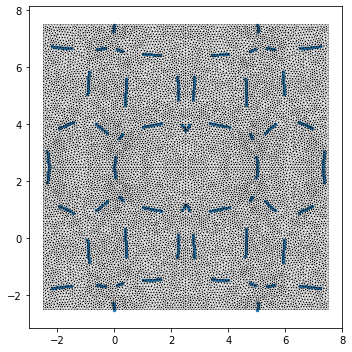

In [177]:

m = MeshFEM.mesh.Mesh('../../experiments/parallelized_experiments/output/voronoi_5/2024_01_08_16_21//{}/mesh_voronoi_5_{}.obj'.format(index, index))
fusing_vtx = np.load('../../experiments/parallelized_experiments/output/voronoi_5/2024_01_08_16_21/{}/fusedVtx_voronoi_5_{}.npy'.format(index, index))

vertices = m.vertices()
vertices = np.concatenate((vertices, np.zeros((len(vertices), 1))), axis = 1)
m = MeshFEM.mesh.Mesh(vertices, m.elements())


visualization.plot_2d_mesh(m, pointList=fusing_vtx, width=5, height=5)

ipu = inflation.InflatablePeriodicUnit(m, fusing_vtx, epsilon = 1e-9)
ipu.setVars(np.load('../../experiments/parallelized_experiments/output/voronoi_5/2024_01_08_16_21/{}/voronoi_5_dofs_before_stiffness_{}.npy'.format(index, index)))



viewer = TriMeshViewer(ipu, width=600, height=600)
viewer.showWireframe(True)
viewer.show()

In [178]:
import parametrization_helper

In [179]:
parametrization_helper.export_top_bottom_mesh(ipu.sheet, './', tag, 'voronoi_5')

m.save("mesh_voronoi_5_{}.obj".format(tag))
np.save("fusedVtx_voronoi_5_{}.npy".format(tag), fusing_vtx)

In [180]:
import experiment_helper

In [181]:
# pressure = 0.8
stiffness_pressure = 0.4
scale_factor_pressure = 0.01

In [182]:
allowBending = False
useTFT = True
disableFusedRegionTFT = False

In [183]:
def cb(i):
    viewer.update(scalarField=utils.getStrains(ipu.sheet)[:, 0])

In [184]:
# Choose strategy for constraining rigid motion
fixedVars, hessianShift = periodic_unit_helper.get_center_fixedVars(ipu), 0
if not allowBending:
    fixedVars, hessianShift = [ipu.numVars() - 2, ipu.numVars() - 1], 1e-6
else:
    fixedVars, hessianShift = [], 1e-6

ipu.sheet.setUseTensionFieldEnergy(useTFT)
ipu.sheet.setUseHessianProjectedEnergy(False)
if (disableFusedRegionTFT):
    ipu.sheet.disableFusedRegionTensionFieldTheory(False)
ipu.sheet.pressure = stiffness_pressure

benchmark.reset()
print(allowBending, stiffness_pressure, hessianShift, fixedVars)

opts.niter = 500
opts.gradTol = 1e-10
print(opts.factorizer)

cr = inflation.inflation_newton(ipu, fixedVars, options = opts, callback=cb, hessianShift = hessianShift)
viewer.update(scalarField=utils.getStrains(ipu.sheet)[:, 0])
benchmark.report()

False 0.4 1e-06 [79917, 79918]
CholeskyProvider.CatamariNesdis
InflatablePeriodicUnit.hessianSparsityPattern	0.137334	1
    Compress Matrix	0.0589831	2
    InflatablePeriodicUnit.computeAHA	0.0429471	1
    InflatablePeriodicUnit.hessianPeriodicPressurePotential	0.00293708	1
            baseHessianSparsityPattern	1.19209e-06	1
InflatableSheet setVars	0.000506878	1
Newton iterations	0.258764	1
    InflatableSheet energy	0.000967979	3
    Newton iterate	0.257694	1
        Preamble	0.257694	1
            Callback	0.244372	1
                InflatableSheet energy	0.000313044	1
            InflatablePeriodicUnit.getSheetGradient	0.00128412	1
                InflatableSheet gradient	0.00114584	2
            InflatablePeriodicUnit.sensitivitycache.update	0.00922799	1
            InflatableSheet energy	0.00113106	3
Full time	0.641382


In [185]:
# np.save('parallel_tubes.npy', ipu.getVars())

In [186]:
bending_stiffness, alphas, stiffness_coefficients = experiment_helper.helper_compute_bending_stiffness(ipu, cb, result_folder='./', name = tag, variable = 0, render_images = True)

In [187]:
betas = np.linspace(0, np.pi, 1000)
optimizer = inflation.get_inflation_optimizer(ipu, ipu.getStretchingStiffnessFixedVars(), opts, callback=cb, hessianShift = hessianShiftForStiffness)
stretchingStiffness = inflation.getStretchingStiffness(ipu, betas, optimizer, hessianShiftForStiffness, ipu.getStretchingStiffnessFixedVars())


In [188]:
stiffness_data_collection.append([bending_stiffness, stretchingStiffness, alphas, stiffness_coefficients])

### Pattern 5: Max kappa

In [189]:
index = df['name'][np.argmax(np.abs(df['Simulation Kappa value']))]

In [190]:
tag = 'max_kappa'
labels.append(tag)

Renderer(camera=PerspectiveCamera(children=(PointLight(color='#999999', position=(0.0, 0.0, 5.0), quaternion=(…

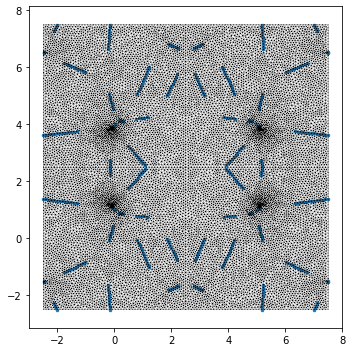

In [191]:

m = MeshFEM.mesh.Mesh('../../experiments/parallelized_experiments/output/voronoi_5/2024_01_08_16_21//{}/mesh_voronoi_5_{}.obj'.format(index, index))
fusing_vtx = np.load('../../experiments/parallelized_experiments/output/voronoi_5/2024_01_08_16_21/{}/fusedVtx_voronoi_5_{}.npy'.format(index, index))

vertices = m.vertices()
vertices = np.concatenate((vertices, np.zeros((len(vertices), 1))), axis = 1)
m = MeshFEM.mesh.Mesh(vertices, m.elements())


visualization.plot_2d_mesh(m, pointList=fusing_vtx, width=5, height=5)

ipu = inflation.InflatablePeriodicUnit(m, fusing_vtx, epsilon = 1e-9)
ipu.setVars(np.load('../../experiments/parallelized_experiments/output/voronoi_5/2024_01_08_16_21/{}/voronoi_5_dofs_before_stiffness_{}.npy'.format(index, index)))



viewer = TriMeshViewer(ipu, width=600, height=600)
viewer.showWireframe(True)
viewer.show()

In [192]:
import parametrization_helper

In [193]:
parametrization_helper.export_top_bottom_mesh(ipu.sheet, './', tag, 'voronoi_5')

m.save("mesh_voronoi_5_{}.obj".format(tag))
np.save("fusedVtx_voronoi_5_{}.npy".format(tag), fusing_vtx)

In [194]:
import experiment_helper

In [195]:
# pressure = 0.8
stiffness_pressure = 0.4
scale_factor_pressure = 0.01

In [196]:
allowBending = False
useTFT = True
disableFusedRegionTFT = False

In [197]:
def cb(i):
    viewer.update(scalarField=utils.getStrains(ipu.sheet)[:, 0])

In [198]:
# Choose strategy for constraining rigid motion
fixedVars, hessianShift = periodic_unit_helper.get_center_fixedVars(ipu), 0
if not allowBending:
    fixedVars, hessianShift = [ipu.numVars() - 2, ipu.numVars() - 1], 1e-6
else:
    fixedVars, hessianShift = [], 1e-6

ipu.sheet.setUseTensionFieldEnergy(useTFT)
ipu.sheet.setUseHessianProjectedEnergy(False)
if (disableFusedRegionTFT):
    ipu.sheet.disableFusedRegionTensionFieldTheory(False)
ipu.sheet.pressure = stiffness_pressure

benchmark.reset()
print(allowBending, stiffness_pressure, hessianShift, fixedVars)

opts.niter = 500
opts.gradTol = 1e-10
print(opts.factorizer)

cr = inflation.inflation_newton(ipu, fixedVars, options = opts, callback=cb, hessianShift = hessianShift)
viewer.update(scalarField=utils.getStrains(ipu.sheet)[:, 0])
benchmark.report()

False 0.4 1e-06 [88683, 88684]
CholeskyProvider.CatamariNesdis
InflatablePeriodicUnit.hessianSparsityPattern	0.140969	1
    Compress Matrix	0.0569212	2
    InflatablePeriodicUnit.computeAHA	0.046448	1
    InflatablePeriodicUnit.hessianPeriodicPressurePotential	0.00309801	1
            baseHessianSparsityPattern	0	1
InflatableSheet setVars	0.000570059	1
Newton iterations	0.276556	1
    InflatableSheet energy	0.001091	3
    Newton iterate	0.275357	1
        Preamble	0.275355	1
            Callback	0.243179	1
                InflatableSheet energy	0.000359058	1
            InflatablePeriodicUnit.getSheetGradient	0.0016129	1
                InflatableSheet gradient	0.00146008	2
            InflatablePeriodicUnit.sensitivitycache.update	0.0268331	1
            InflatableSheet energy	0.0013032	3
Full time	0.658377


In [199]:
# np.save('parallel_tubes.npy', ipu.getVars())

In [200]:
# bending_stiffness, alphas, stiffness_coefficients = experiment_helper.helper_compute_bending_stiffness(ipu, cb, result_folder='./', name = tag, variable = 0, render_images = True)

In [201]:
# betas = np.linspace(0, np.pi, 1000)
# optimizer = inflation.get_inflation_optimizer(ipu, ipu.getStretchingStiffnessFixedVars(), opts, callback=cb, hessianShift = hessianShiftForStiffness)
# stretchingStiffness = inflation.getStretchingStiffness(ipu, betas, optimizer, hessianShiftForStiffness, ipu.getStretchingStiffnessFixedVars())


In [202]:
# stiffness_data_collection.append([bending_stiffness, stretchingStiffness, alphas, stiffness_coefficients])

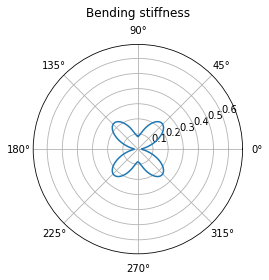

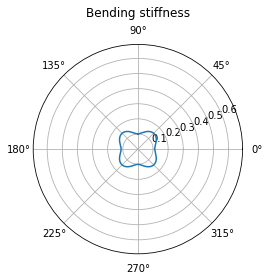

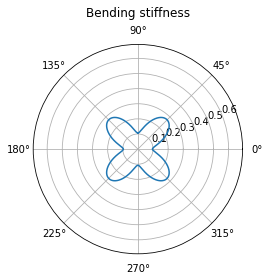

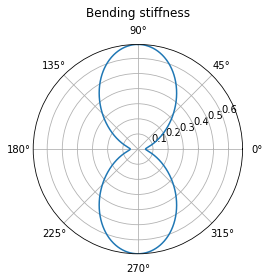

In [203]:
# Then plot the three families

# First get the max values of the bending stiffness and stretching stiffness
bending_stiffness_collection = [data[0] for data in stiffness_data_collection]
stretching_stiffness_collection = [data[1] for data in stiffness_data_collection]


for i in range(4):

    fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
    ax.set_title("Bending stiffness", va='bottom')
    plt.tight_layout()
    
    data = stiffness_data_collection[i]
    label = labels[i]

    bending_stiffness, stretching_stiffness, alphas, stiffness_coefficients = data

    sampled_stiffness = (bending_stiffness)
    r = list(sampled_stiffness) + list(sampled_stiffness)
    theta = np.array(list(alphas) + list(np.pi + np.array(alphas))) + np.pi / 2


    ax.plot(theta, r, )
    
    ax.set_rmax(np.max(bending_stiffness_collection))
    ax.set_rmin(0)
    ax.grid(True)
    fig.savefig("{}_bending_stiffness.svg".format(label), dpi = 300)

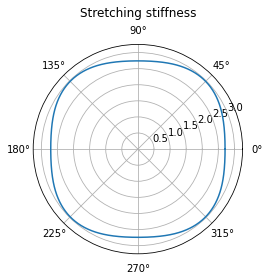

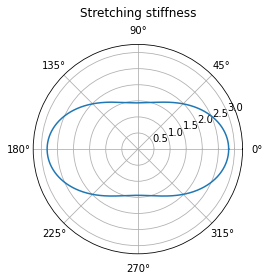

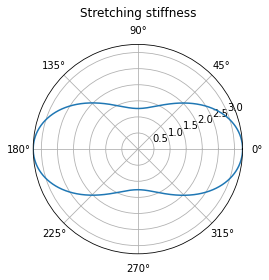

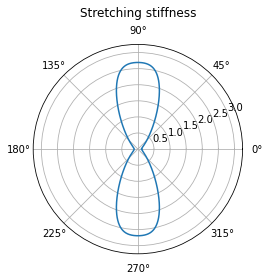

In [205]:
for i in np.arange(4):

    fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
    ax.set_title("Stretching stiffness", va='bottom')
    plt.tight_layout()
    
    data = stiffness_data_collection[i]
    label = labels[i]

    bending_stiffness, stretching_stiffness, alphas, stiffness_coefficients = data
    sampled_stiffness = (stretching_stiffness)
    r = list(sampled_stiffness) + list(sampled_stiffness)
    theta = np.array(list(alphas) + list(np.pi + np.array(alphas)))


    ax.plot(theta, r, )
    
    ax.set_rmax(np.max(stretching_stiffness_collection))
    ax.set_rmin(0)
    ax.grid(True)
    fig.savefig("{}_stretching_stiffness.svg".format(label), dpi = 300)